# Data Explorations

Notebook to explore some of the ERA5 data, and get a feel for what's going on.

In [1]:
import xarray as xr
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
temp_dat = xr.load_dataset('~/extreme_antarctic_ARs/data/concordia_2m_temp.nc')
ewvf_dat = xr.load_dataset('~/extreme_antarctic_ARs/data/concordia_e_wvf.nc')
nwvf_dat = xr.load_dataset('~/extreme_antarctic_ARs/data/concordia_n_wvf.nc')

tot_dat = xr.merge([temp_dat, ewvf_dat, nwvf_dat])
tot_dat = tot_dat.rename_vars({'t2m':'temp2m', 'p71.162':'ewvf', 'p72.162':'nwvf'})
tot_dat['temp2m'] = tot_dat['temp2m'] - 273.15
tot_dat['nwvf'] = tot_dat['nwvf']*(-1)
tot_dat = tot_dat.rename_vars({'nwvf':'swvf'})

In [3]:
one_cell = tot_dat.sel(longitude=123.0, latitude=-75.0)
daily_maxima = one_cell.groupby('time.date').max()
daily_maxima['date'] = pd.DatetimeIndex(daily_maxima.date)

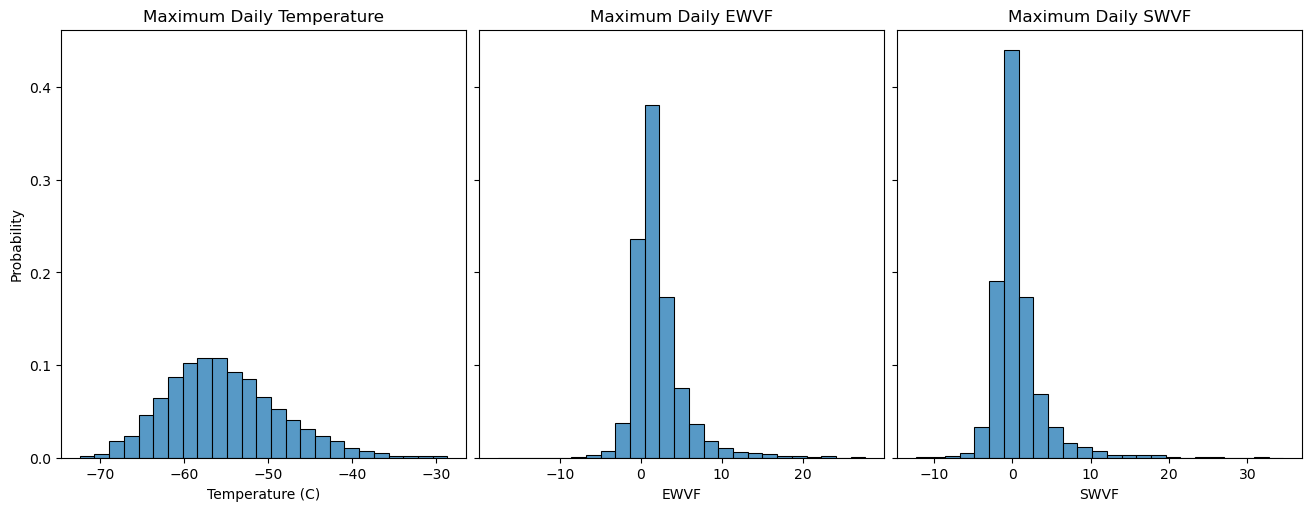

In [4]:
fig, axs = plt.subplots(nrows=1, ncols=3, layout='constrained', figsize=(13,5), sharey=True)
sns.histplot(data=daily_maxima.temp2m, bins = 25, ax=axs[0], stat='probability')
axs[0].set_title('Maximum Daily Temperature')
axs[0].set_xlabel('Temperature (C)')
sns.histplot(data=daily_maxima.ewvf, bins = 25, ax=axs[1], stat='probability')
axs[1].set_title('Maximum Daily EWVF')
axs[1].set_xlabel('EWVF')
sns.histplot(data=daily_maxima.swvf, bins = 25, ax=axs[2], stat='probability')
axs[2].set_title('Maximum Daily SWVF')
axs[2].set_xlabel('SWVF');

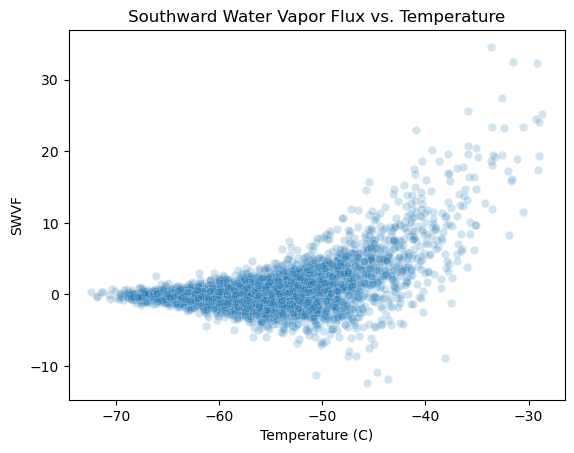

In [5]:
sns.scatterplot(data=daily_maxima, x='temp2m', y='swvf', alpha=0.2)
plt.title('Southward Water Vapor Flux vs. Temperature')
plt.ylabel('SWVF')
plt.xlabel('Temperature (C)');

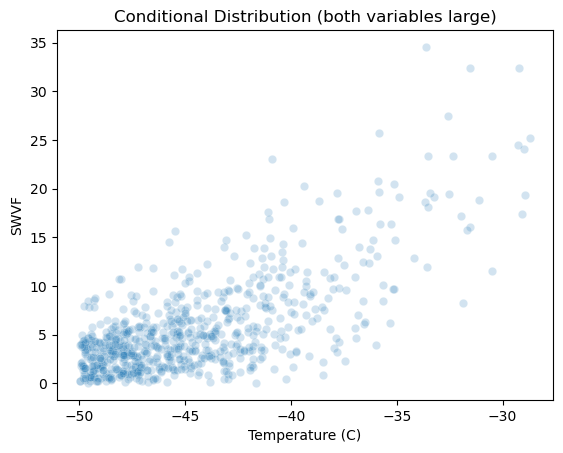

In [6]:
upper_right = daily_maxima.where((daily_maxima['temp2m'] >= -50) & (daily_maxima['swvf'] >= 0), drop=True)
sns.scatterplot(data=upper_right, x='temp2m', y='swvf', alpha=0.2)
plt.title('Conditional Distribution (both variables large)')
plt.ylabel('SWVF')
plt.xlabel('Temperature (C)');

In [11]:
daily_max_df = daily_maxima.to_dataframe()


'date,temp2m,ewvf,swvf,latitude,longitude\n2000-04-01,-52.494324,-1.2829915,-0.84034204,-75.0,123.0\n2000-04-02,-50.790833,-1.8255298,-1.1487303,-75.0,123.0\n2000-04-03,-52.20668,2.5369022,-1.1694093,-75.0,123.0\n2000-04-04,-53.550034,1.9029789,-2.7778845,-75.0,123.0\n2000-04-05,-53.476776,-1.145433,-0.7486348,-75.0,123.0\n2000-04-06,-58.17775,-0.7000513,-0.7962866,-75.0,123.0\n2000-04-07,-55.97841,-1.052124,-1.3303471,-75.0,123.0\n2000-04-08,-56.706375,0.57837695,-1.1891894,-75.0,123.0\n2000-04-09,-60.33313,0.80732054,-1.4634123,-75.0,123.0\n2000-04-10,-59.056854,2.9428442,-2.6708922,-75.0,123.0\n2000-04-11,-60.06862,2.8476114,-1.9615092,-75.0,123.0\n2000-04-12,-60.756485,1.7211707,-2.076593,-75.0,123.0\n2000-04-13,-58.5587,1.7173231,-2.826435,-75.0,123.0\n2000-04-14,-55.828033,1.2873323,-4.2119355,-75.0,123.0\n2000-04-15,-54.786194,3.5248225,-4.1229253,-75.0,123.0\n2000-04-16,-54.90573,3.6720002,-3.0934653,-75.0,123.0\n2000-04-17,-60.262177,4.9436946,-3.5807729,-75.0,123.0\n2000-04-1